In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [62]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [63]:
df.shape

(1338, 7)

In [64]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [66]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [67]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [68]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

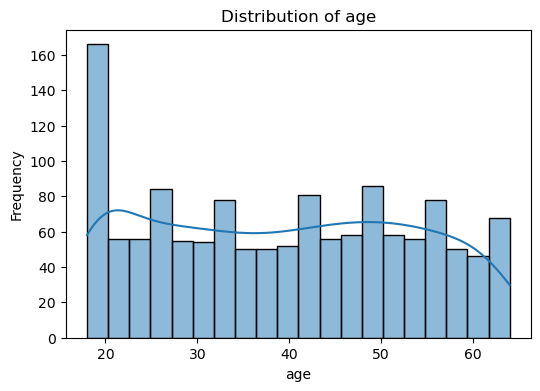

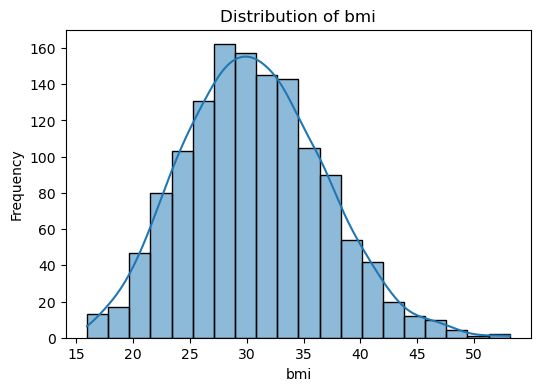

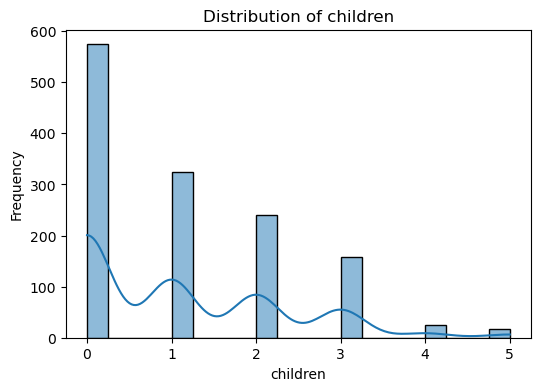

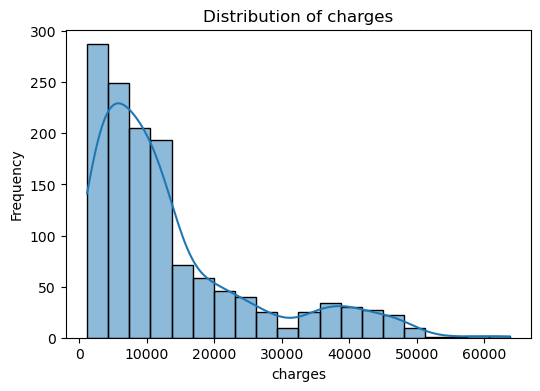

In [69]:
numeric_colums = ['age', 'bmi', 'children', 'charges']
for col in numeric_colums:
    plt.figure(figsize = (6, 4))
    sns.histplot(df[col], kde = True, bins = 20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


<Axes: xlabel='children', ylabel='count'>

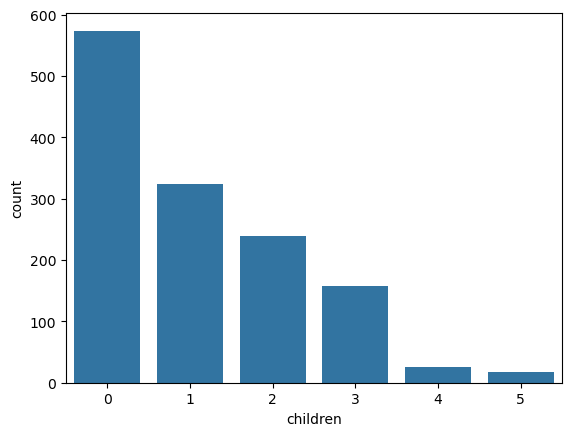

In [70]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

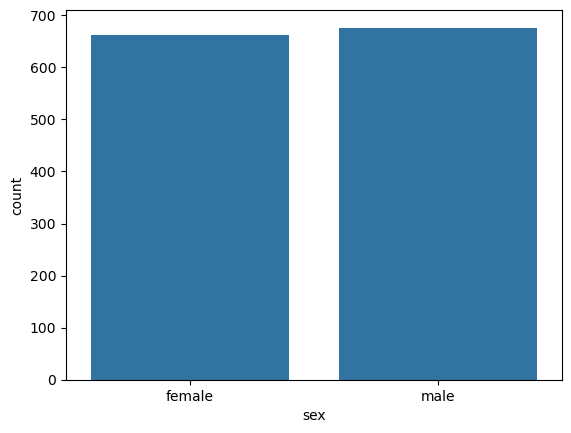

In [71]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

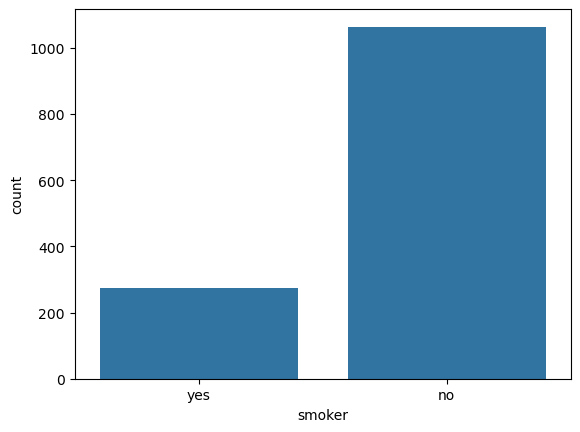

In [72]:
sns.countplot(x= df['smoker'])

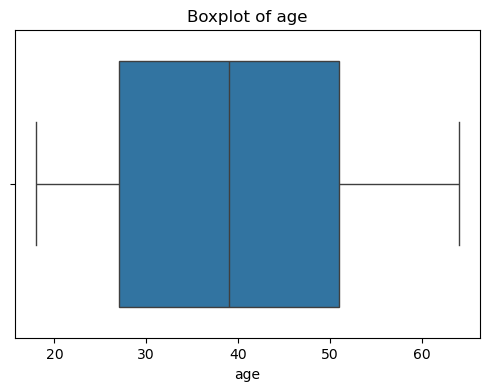

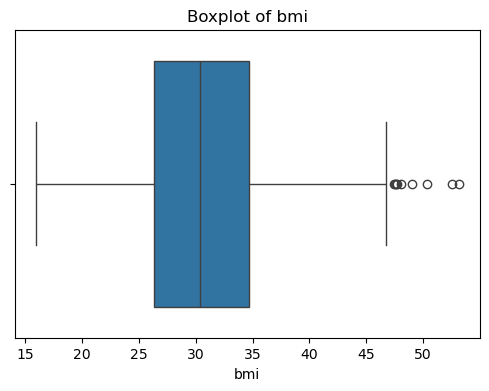

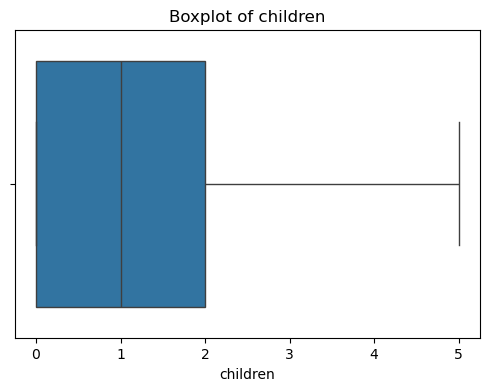

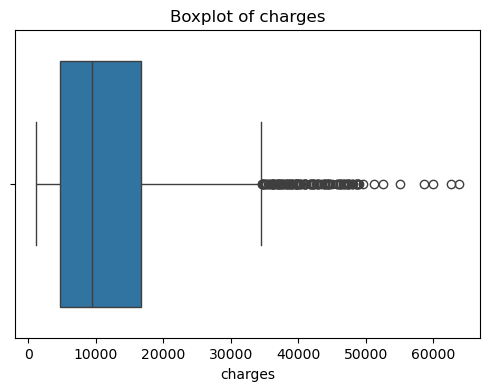

In [73]:
for col in numeric_colums:
    plt.figure(figsize = (6, 4))
    sns.boxplot(x = df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

<Axes: >

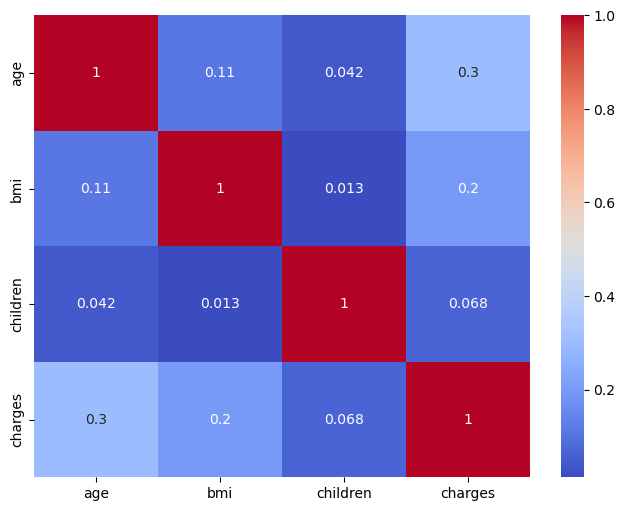

In [74]:
plt.figure(figsize = (8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Data Cleaning and Preprocessing

In [75]:
df_cleaned = df.copy()

In [76]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [77]:
df_cleaned.shape

(1338, 7)

In [78]:
df_cleaned.drop_duplicates(inplace = True)

In [79]:
df_cleaned.shape

(1337, 7)

In [80]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [81]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [82]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [83]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})

In [84]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [85]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [86]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no":0, "yes":1})

In [87]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [88]:
df_cleaned.rename(columns = {
    'sex': 'is_female', 
    'smoker': 'is_smoker'
    }, inplace = True)

In [89]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [90]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [91]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'])

In [92]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [93]:
df_cleaned = df_cleaned.astype(int)

In [94]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

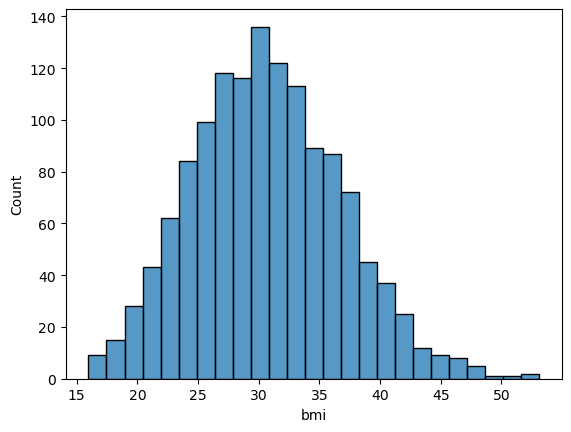

In [95]:
sns.histplot(df['bmi'])

In [96]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float('inf')],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,Obese
1334,18,1,31,0,0,2205,1,0,0,0,Obese
1335,18,1,36,0,0,1629,0,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,0,1,Overweight


In [97]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['bmi_category'])

In [98]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [99]:
df_cleaned = df_cleaned.astype(int)

In [100]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [101]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [102]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned

# transform = (original value - mean) / standard deviation

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1,0,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,1,0,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,0,1,0,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,0,1,0,0,1,0


In [103]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------    

# List of features to check against the target variable 'charges'
selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker',
                     'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest',
                     'bmi_category_Underweight', 'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
                     ]


correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}


correlation_df = pd.DataFrame(list(correlations.items()), columns = ['Feature', 'Pearson Correlation with Charges'])
correlation_df.sort_values(by = 'Pearson Correlation with Charges', ascending = False, inplace = True)
correlation_df

cat_features = [
    'is_female',
    'is_smoker',
    'region_northeast',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Underweight',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]


In [104]:
from scipy.stats import chi2_contingency

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q = 4, labels = ['Q1', 'Q2', 'Q3', 'Q4'])
chi2_results = {}

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

    decision = "Reject NUll (Keep  Feature)" if p_val < alpha else "Accept Null (Drop Feature)"
    chi2_results[col] = {
        'chi2 Statistic': chi2_stat,
        'p-value': p_val,
        'Degrees of Freedom': dof,
        'Decision': decision
    }

    chi2_df = pd.DataFrame(chi2_results).T
    chi2_df = chi2_df.sort_values(by = 'p-value')

In [105]:
chi2_df

,chi2 Statistic,p-value,Degrees of Freedom,Decision
is_smoker,848.219178,0.0,3,Reject NUll (Keep Feature)
region_southeast,15.998167,0.001135,3,Reject NUll (Keep Feature)
is_female,10.258784,0.01649,3,Reject NUll (Keep Feature)
bmi_category_Obese,8.515711,0.036473,3,Reject NUll (Keep Feature)
region_northeast,6.438442,0.092122,3,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,3,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,3,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,3,Accept Null (Drop Feature)
bmi_category_Underweight,3.37403,0.337471,3,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,3,Accept Null (Drop Feature)


In [106]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_Obese']]
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [107]:
from sklearn.model_selection import train_test_split


In [108]:
X = final_df.drop('charges', axis = 1)
y = final_df['charges']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [110]:
from sklearn.linear_model import LinearRegression


In [111]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [112]:
y_pred = model.predict(X_test)


In [113]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.8040712413347118

In [ ]:
n = X_test.shape[0] # number of observations(number of rows)
p = X_test.shape[1] # number of predictors(number of columns)

adjusted_r2 = 1 - ((1- r2) * (n - 1) / (n - p - 1))
adjusted_r2


0.7987962362937232